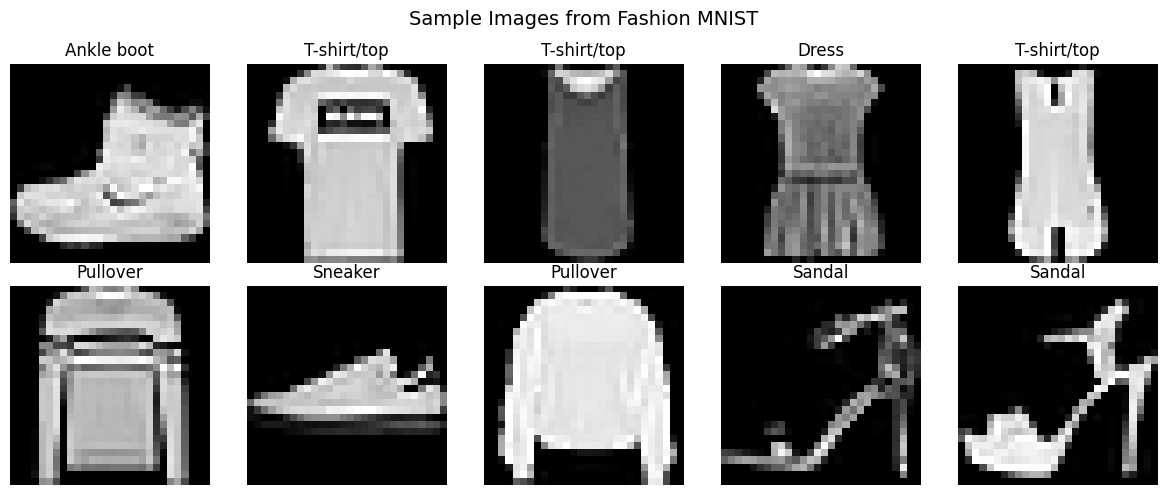

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Load Fashion MNIST data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Define class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualize 10 sample images from the training set
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Sample Images from Fashion MNIST", fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Flatten the images for ANN input
x_train_flat = x_train_norm.reshape((x_train_norm.shape[0], -1))
x_test_flat = x_test_norm.reshape((x_test_norm.shape[0], -1))

# One-hot encode the labels
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)

# Confirm shapes
print("x_train_flat shape:", x_train_flat.shape)
print("y_train_oh shape:", y_train_oh.shape)


x_train_flat shape: (60000, 784)
y_train_oh shape: (60000, 10)


In [7]:
from skimage.feature import hog, local_binary_pattern

# Parameters for HOG and LBP
hog_params = {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys'}
lbp_radius = 1
lbp_points = 8 * lbp_radius

# Extract HOG features
hog_train = [hog(img, **hog_params) for img in x_train]
hog_test = [hog(img, **hog_params) for img in x_test]
hog_train = np.array(hog_train)
hog_test = np.array(hog_test)

# Extract LBP features and flatten
def extract_lbp_features(images):
    lbp_features = []
    for img in images:
        lbp = local_binary_pattern(img, lbp_points, lbp_radius, method='uniform')
        lbp_flat = lbp.flatten()
        lbp_features.append(lbp_flat)
    return np.array(lbp_features)

lbp_train = extract_lbp_features(x_train)
lbp_test = extract_lbp_features(x_test)

print("HOG feature shape:", hog_train.shape)
print("LBP feature shape:", lbp_train.shape)


HOG feature shape: (60000, 144)
LBP feature shape: (60000, 784)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Function to create a simple ANN
def create_ann(input_dim, hidden_units=128):
    model = Sequential([
        Dense(hidden_units, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [9]:
# Train model on raw pixels
model_raw = create_ann(x_train_flat.shape[1])
model_raw.fit(x_train_flat, y_train_oh, epochs=5, batch_size=128, verbose=1, validation_split=0.1)

# Train model on HOG features
model_hog = create_ann(hog_train.shape[1])
model_hog.fit(hog_train, y_train_oh, epochs=5, batch_size=128, verbose=1, validation_split=0.1)

# Train model on LBP features
model_lbp = create_ann(lbp_train.shape[1])
model_lbp.fit(lbp_train, y_train_oh, epochs=5, batch_size=128, verbose=1, validation_split=0.1)


c:\Users\PMLS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7355 - loss: 0.7693 - val_accuracy: 0.8460 - val_loss: 0.4308
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8558 - loss: 0.4110 - val_accuracy: 0.8552 - val_loss: 0.3955
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8695 - loss: 0.3683 - val_accuracy: 0.8702 - val_loss: 0.3524
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8784 - loss: 0.3320 - val_accuracy: 0.8715 - val_loss: 0.3535
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8875 - loss: 0.3091 - val_accuracy: 0.8743 - val_loss: 0.3337
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6372 - loss: 1.1220 - val_accuracy: 0.8060 - val_loss: 0.5270
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8027 - loss: 0.5332 - val_accuracy: 0.8127 - val_loss: 0.5029
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8138 - loss: 0.4977 - val_accuracy: 0.8195 - v

In [10]:
# Evaluate accuracy
acc_raw = model_raw.evaluate(x_test_flat, y_test_oh, verbose=0)[1]
acc_hog = model_hog.evaluate(hog_test, y_test_oh, verbose=0)[1]
acc_lbp = model_lbp.evaluate(lbp_test, y_test_oh, verbose=0)[1]

print(f"Accuracy - Raw Pixels: {acc_raw:.4f}")
print(f"Accuracy - HOG Features: {acc_hog:.4f}")
print(f"Accuracy - LBP Features: {acc_lbp:.4f}")

# Get predictions
pred_raw = np.argmax(model_raw.predict(x_test_flat), axis=1)
pred_hog = np.argmax(model_hog.predict(hog_test), axis=1)
pred_lbp = np.argmax(model_lbp.predict(lbp_test), axis=1)


Accuracy - Raw Pixels: 0.8728
Accuracy - HOG Features: 0.8209
Accuracy - LBP Features: 0.7672
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [11]:
def calculate_metrics(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    precision = []
    recall = []
    f1 = []

    for i in range(num_classes):
        tp = cm[i, i]
        fp = sum(cm[:, i]) - tp
        fn = sum(cm[i, :]) - tp
        precision_i = tp / (tp + fp + 1e-9)
        recall_i = tp / (tp + fn + 1e-9)
        f1_i = 2 * precision_i * recall_i / (precision_i + recall_i + 1e-9)
        precision.append(precision_i)
        recall.append(recall_i)
        f1.append(f1_i)

    return cm, precision, recall, f1

# Calculate metrics for each
cm_raw, p_raw, r_raw, f1_raw = calculate_metrics(y_test, pred_raw)
cm_hog, p_hog, r_hog, f1_hog = calculate_metrics(y_test, pred_hog)
cm_lbp, p_lbp, r_lbp, f1_lbp = calculate_metrics(y_test, pred_lbp)


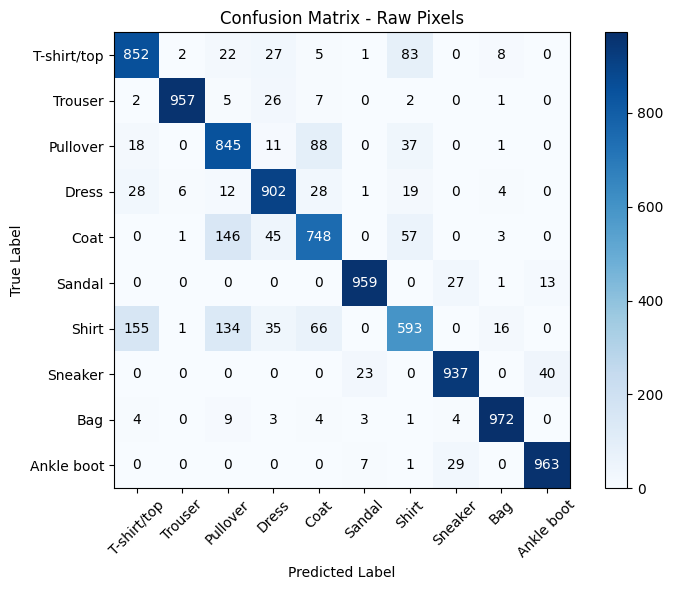

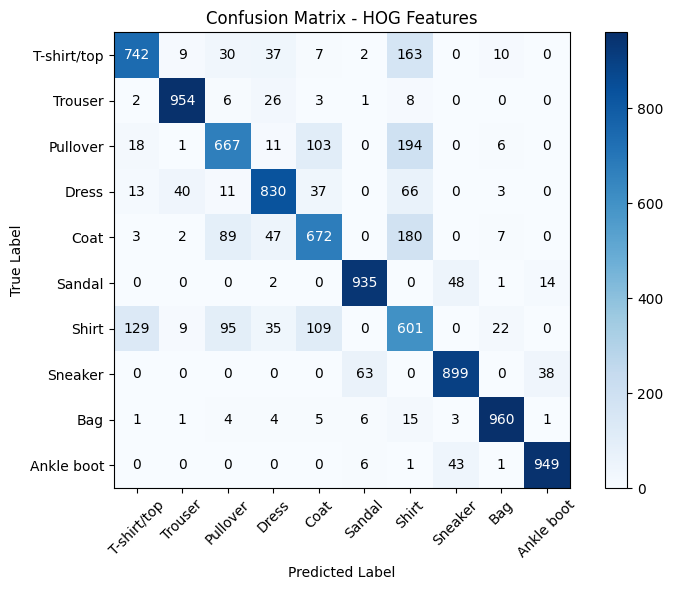

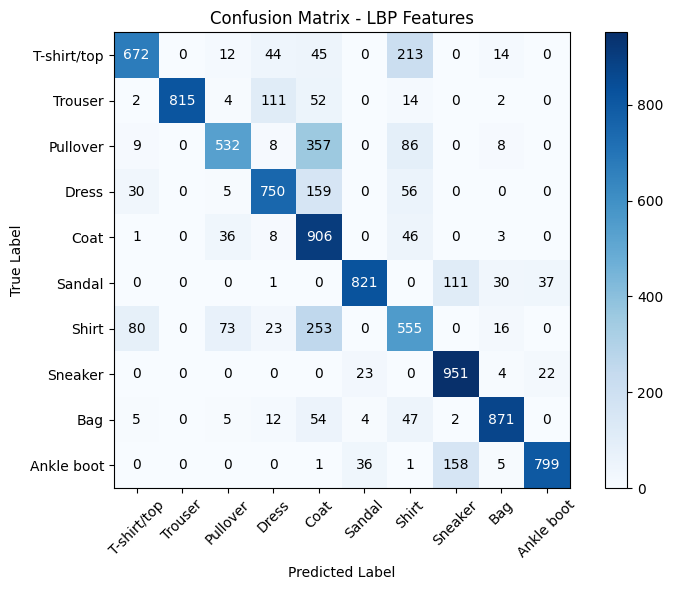

In [12]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    thresh = cm.max() / 2
    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, str(cm[i, j]), 
                     ha="center", va="center", 
                     color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Plot for all three feature sets
plot_confusion_matrix(cm_raw, "Confusion Matrix - Raw Pixels")
plot_confusion_matrix(cm_hog, "Confusion Matrix - HOG Features")
plot_confusion_matrix(cm_lbp, "Confusion Matrix - LBP Features")


In [13]:
def print_summary(name, acc, prec, rec, f1):
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Average Precision: {np.mean(prec):.4f}")
    print(f"Average Recall: {np.mean(rec):.4f}")
    print(f"Average F1 Score: {np.mean(f1):.4f}")

print_summary("Raw Pixels", acc_raw, p_raw, r_raw, f1_raw)
print_summary("HOG Features", acc_hog, p_hog, r_hog, f1_hog)
print_summary("LBP Features", acc_lbp, p_lbp, r_lbp, f1_lbp)



=== Raw Pixels ===
Accuracy: 0.8728
Average Precision: 0.8732
Average Recall: 0.8728
Average F1 Score: 0.8714

=== HOG Features ===
Accuracy: 0.8209
Average Precision: 0.8266
Average Recall: 0.8209
Average F1 Score: 0.8227

=== LBP Features ===
Accuracy: 0.7672
Average Precision: 0.8016
Average Recall: 0.7672
Average F1 Score: 0.7720
